In [68]:
import pandas as pd
import csv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import pearsonr, spearmanr, gaussian_kde

In [69]:
filename = 'data/final_enr.csv'
columns = ['diseaseId', '#snp', '#border_snp', 'pval_tad', 'pval_border', 'pval_outside', 'is_cancer', 'window_size', 'filter']
df = pd.read_csv(filename, usecols=columns)
print(df.head)

<bound method NDFrame.head of              diseaseId  #snp  #border_snp  pval_tad  pval_border  \
0          EFO_0000094    22           13  0.000000     0.000000   
1          EFO_0000095   130           72  0.000000     0.000000   
2          EFO_0000096    13            6  0.000000     0.000000   
3          EFO_0000174     7            3  0.000000     0.000000   
4          EFO_0000178    37           16  0.000000     0.000000   
...                ...   ...          ...       ...          ...   
71741    Orphanet_1945    11            0       NaN          NaN   
71742  Orphanet_391311    15            5  0.950432     0.172214   
71743     Orphanet_654     7            3  0.969582     0.088117   
71744   Orphanet_93957     3            0       NaN          NaN   
71745   Orphanet_98974     7            2  0.730591     0.294210   

       pval_outside  is_cancer  window_size     filter  
0          1.000000      False            0   nofilter  
1          1.000000      False         

In [70]:
df.head()

,diseaseId,#snp,#border_snp,pval_tad,pval_border,pval_outside,is_cancer,window_size,filter
0,EFO_0000094,22,13,0.0,0.0,1.0,False,0,nofilter
1,EFO_0000095,130,72,0.0,0.0,1.0,False,0,nofilter
2,EFO_0000096,13,6,0.0,0.0,1.0,False,0,nofilter
3,EFO_0000174,7,3,0.0,0.0,1.0,True,0,nofilter
4,EFO_0000178,37,16,0.0,0.0,1.0,True,0,nofilter


In [71]:
import numpy as np

# Avoid log(0) or log of negative values
#df['pval_border'] = df['pval_border'].clip(lower=1e-300)
df['log10_pval_border'] = -np.log10(df['pval_border'])

/Users/aliaarman/TADandPPI/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [72]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['log10_pval_border'])

In [73]:
df_cancers = pd.read_csv("data/cancerous_clustering_biogrid.csv", usecols=['efoID', 'z_score', 'pvalue', 'p_empirical'])
df_cancers = df_cancers.rename(columns={'efoID': 'diseaseId'})
df_cancers.shape

(47, 4)

In [74]:
df_noncancers = pd.read_csv("data/noncancerous_clustering_biogrid.csv", usecols=['efoID', 'z_score', 'pvalue', 'p_empirical'])
df_noncancers = df_noncancers.rename(columns={'efoID': 'diseaseId'})
df_noncancers.shape

(313, 4)

In [75]:
combined = pd.concat([df_cancers, df_noncancers])

In [76]:
combined.head()

,diseaseId,z_score,pvalue,p_empirical
0,EFO_0004193,13.098661,NaN,0.000999
1,EFO_0000707,5.391684,NaN,0.011988
2,EFO_0010176,9.102589,NaN,0.001998
3,EFO_0000389,19.820597,NaN,0.000999
4,MONDO_0005575,3.947404,NaN,0.005994


In [77]:
# only for string
#combined['log10_pval_ppi'] = -np.log10(combined['pvalue'])
combined = combined.replace([np.inf, -np.inf], np.nan)
combined = combined.dropna(subset=['z_score'])
#combined = combined.dropna(subset=['log10_pval_ppi'])

In [78]:
combined_df = pd.merge(df, combined, on='diseaseId', how='inner', indicator=True)
combined_df = combined_df.replace([np.inf, -np.inf], np.nan)
combined_df = combined_df.dropna(subset=['log10_pval_border'])

In [79]:
combined_df.head()

,diseaseId,#snp,#border_snp,pval_tad,pval_border,pval_outside,is_cancer,window_size,filter,log10_pval_border,z_score,pvalue,p_empirical,_merge
0,EFO_0000095,130,52,1.0,4.149095e-04,1.0,False,3,nofilter,3.382047,19.829392,NaN,0.000999,both
1,EFO_0000183,46,21,1.0,4.127834e-03,1.0,False,3,nofilter,2.384278,2.841355,NaN,0.023976,both
2,EFO_0000195,261,101,1.0,3.054780e-06,1.0,False,3,nofilter,5.515020,12.106012,NaN,0.000999,both
3,EFO_0000274,111,40,1.0,1.636998e-02,1.0,False,3,nofilter,1.785952,7.330949,NaN,0.001998,both
4,EFO_0000275,373,161,1.0,6.255159e-14,1.0,False,3,nofilter,13.203762,9.911784,NaN,0.000999,both


In [80]:
combined_df.shape

(20727, 14)

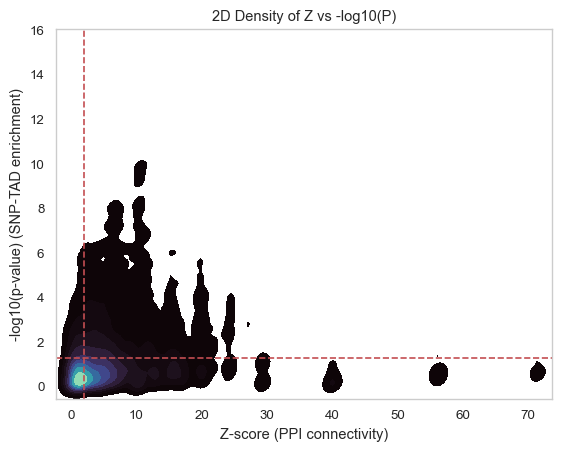

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


sns.kdeplot(
    data=combined_df, x="z_score", y="log10_pval_border", cmap="mako", fill=True, bw_adjust=0.5
)
plt.axhline(-np.log10(0.05), ls='--', color='r')
plt.axvline(2, ls='--', color='r')
plt.title("2D Density of Z vs -log10(P)")
plt.xlabel("Z-score (PPI connectivity)")
plt.ylabel("-log10(p-value) (SNP-TAD enrichment)")
plt.show()


In [83]:
import scipy.stats as stats

# Count diseases in each quadrant
combined_df["Quadrant"] = combined_df.apply(lambda x: "Z+P+" if x.z_score > 2 and x['log10_pval_border'] > -np.log10(0.05)
                          else "Z+P-" if x.z_score > 2
                          else "Z-P+" if x['log10_pval_border'] > -np.log10(0.05)
                          else "Z-P-", axis=1)

contingency = pd.crosstab(combined_df["is_cancer"], combined_df["Quadrant"])
chi2, p, dof, ex = stats.chi2_contingency(contingency)
print(f"Chi2 = {chi2}, p-value = {p}")

Chi2 = 318.73451997807433, p-value = 8.763734390539618e-69


In [ ]:
import networkx as nx
from scipy.stats import spearmanr

# Load your PPI network
G = nx.read_edgelist("ppi_network.txt")
# Calculate centrality
centrality = nx.betweenness_centrality(G)
df["Mean_Centrality"] = df["Associated_Genes"].apply(
    lambda genes: np.mean([centrality.get(g, 0) for g in genes.split(",")])
)

# Correlation
corr, pval = spearmanr(df["Mean_Centrality"], df["-log10_p"])
print(f"Spearman rho: {corr}, p = {pval}")


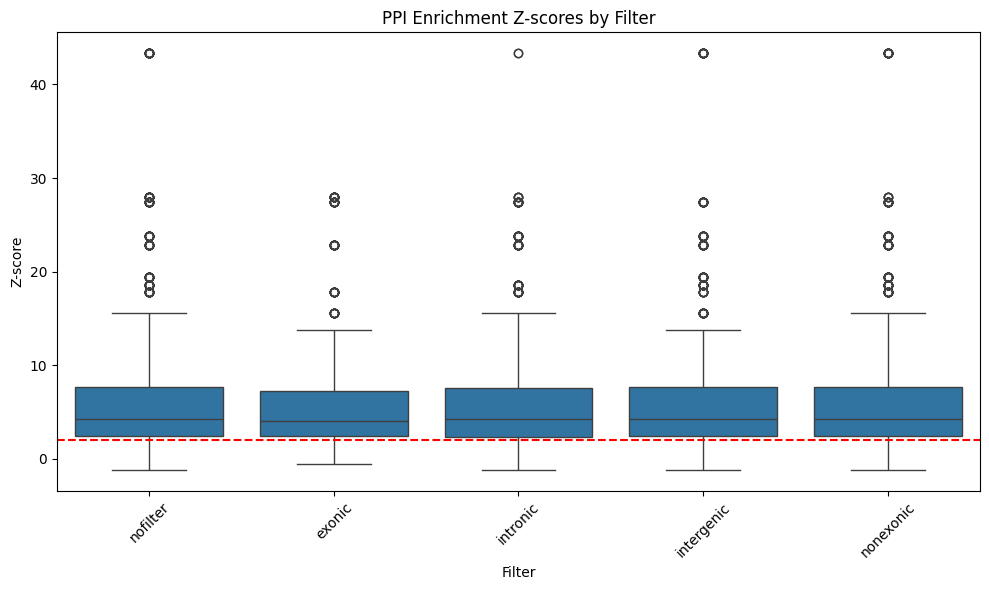

In [178]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='filter', y='z_score', data=combined_df)
plt.title('PPI Enrichment Z-scores by Filter')
plt.axhline(y=2, color='red', linestyle='--', label='z = 2')
plt.ylabel('Z-score')
plt.xlabel('Filter')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

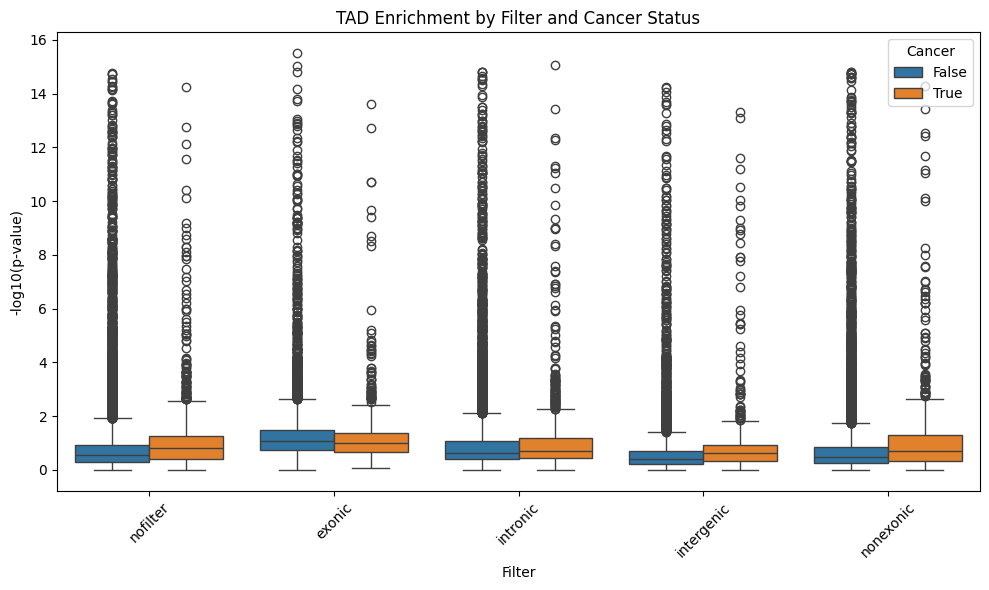

In [179]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='filter', y='log10_pval_border', hue='is_cancer', data=df)
plt.title('TAD Enrichment by Filter and Cancer Status')
plt.ylabel('-log10(p-value)')
plt.xlabel('Filter')
plt.xticks(rotation=45)
plt.legend(title='Cancer')
plt.tight_layout()
plt.show()


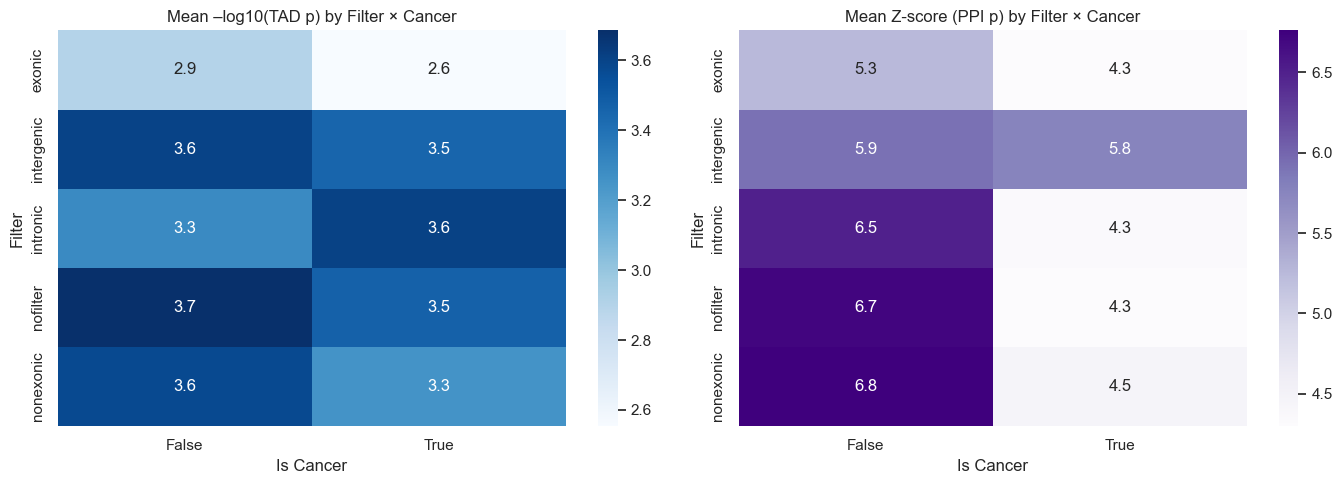

In [37]:
mask = (combined_df['pval_border'] < 0.05) & (combined_df['z_score'] > 2)
sign_df = combined_df.loc[mask]

heat_df = sign_df.groupby(['filter', 'is_cancer'])[['log10_pval_border', 'z_score']].mean().reset_index()
pivot_tad = heat_df.pivot(index='filter', columns='is_cancer', values='log10_pval_border')
pivot_ppi_z = heat_df.pivot(index='filter', columns='is_cancer', values='z_score')

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_tad, annot=True, cmap='Blues', ax=axs[0])
axs[0].set_title('Mean –log10(TAD p) by Filter × Cancer')
axs[0].set_xlabel('Is Cancer')
axs[0].set_ylabel('Filter')

sns.heatmap(pivot_ppi_z, annot=True, cmap='Purples', ax=axs[1])
axs[1].set_title('Mean Z-score (PPI p) by Filter × Cancer')
axs[1].set_xlabel('Is Cancer')
axs[1].set_ylabel('Filter')

plt.tight_layout()
plt.show()


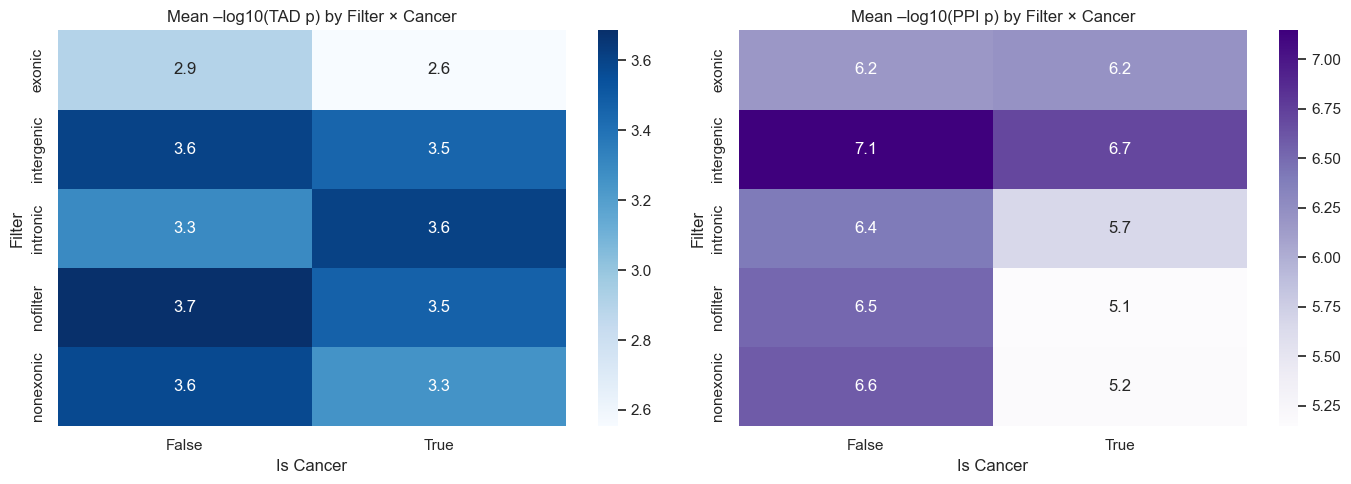

In [38]:
heat_df = sign_df.groupby(['filter', 'is_cancer'])[['log10_pval_border', 'log10_pval_ppi']].mean().reset_index()
pivot_tad = heat_df.pivot(index='filter', columns='is_cancer', values='log10_pval_border')
pivot_ppi = heat_df.pivot(index='filter', columns='is_cancer', values='log10_pval_ppi')

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_tad, annot=True, cmap='Blues', ax=axs[0])
axs[0].set_title('Mean –log10(TAD p) by Filter × Cancer')
axs[0].set_xlabel('Is Cancer')
axs[0].set_ylabel('Filter')

sns.heatmap(pivot_ppi, annot=True, cmap='Purples', ax=axs[1])
axs[1].set_title('Mean –log10(PPI p) by Filter × Cancer')
axs[1].set_xlabel('Is Cancer')
axs[1].set_ylabel('Filter')

plt.tight_layout()
plt.show()


In [39]:
from scipy.stats import spearmanr, pearsonr
mask = (combined_df['pval_border'] < 0.05) & (combined_df['z_score'] > 2)
sign_df = combined_df.loc[mask]

def print_corr(df, label):
    #df = df[df['filter'] == 'intronic']
    print(f'\n{label} (n={len(df)}):')
    print('Spearman:', spearmanr(df['log10_pval_border'], df['z_score']))
    print('Pearson :', pearsonr(df['log10_pval_border'], df['z_score']))

print_corr(sign_df[sign_df['is_cancer']], 'Cancer')
print_corr(sign_df[~sign_df['is_cancer']], 'Noncancer')



Cancer (n=486):
Spearman: SignificanceResult(statistic=np.float64(0.08046684688040193), pvalue=np.float64(0.0763561923311807))
Pearson : PearsonRResult(statistic=np.float64(0.18064240890146765), pvalue=np.float64(6.199752810509546e-05))

Noncancer (n=3086):
Spearman: SignificanceResult(statistic=np.float64(-0.08307352293276492), pvalue=np.float64(3.8189257904752445e-06))
Pearson : PearsonRResult(statistic=np.float64(-0.13163734661701357), pvalue=np.float64(2.1090704937653086e-13))


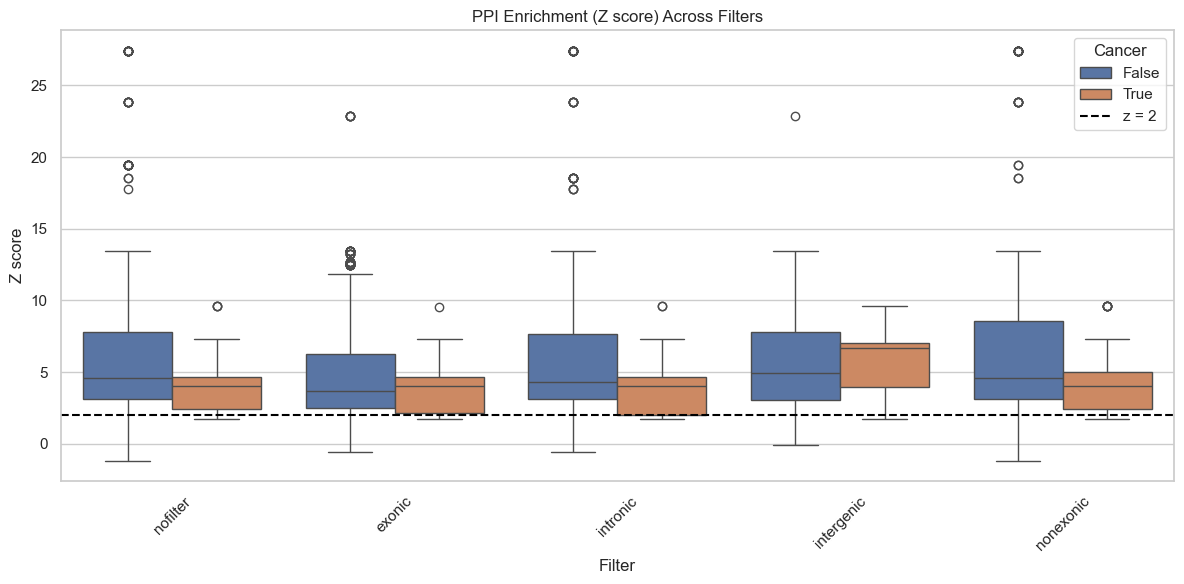

In [309]:
mask = combined_df['pval_border'] < 0.05
sign_df = combined_df.loc[mask]
plt.figure(figsize=(12, 6))
sns.boxplot(data=sign_df, x='filter', y='z_score', hue='is_cancer')
plt.axhline(2, linestyle='--', color='black', label='z = 2')
plt.title('PPI Enrichment (Z score) Across Filters')
plt.ylabel('Z score')
plt.xlabel('Filter')
plt.legend(title='Cancer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


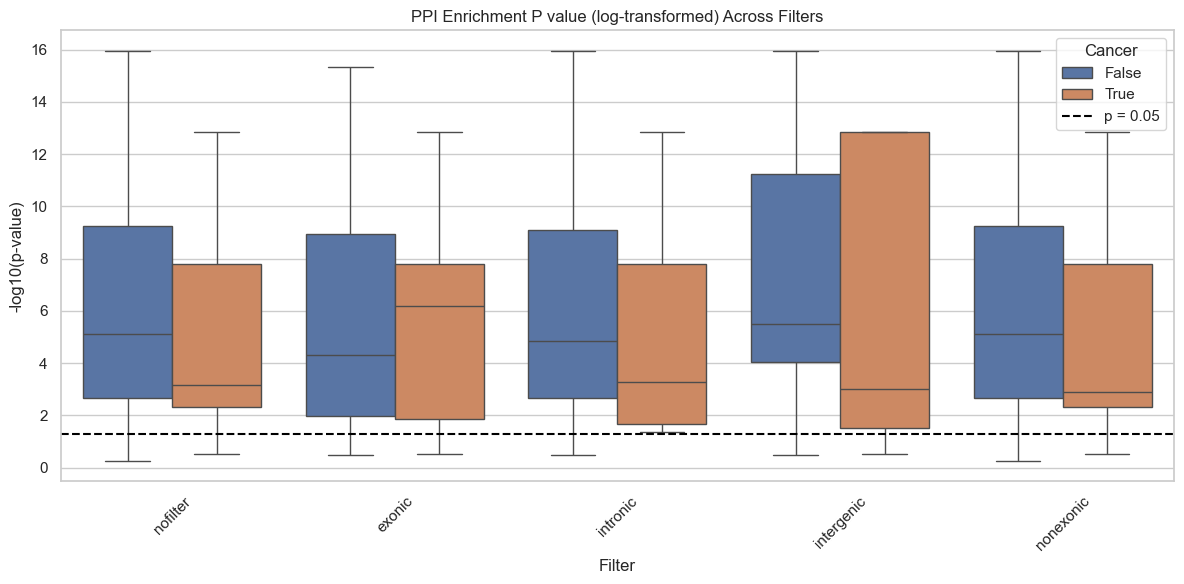

In [310]:
mask = combined_df['pval_border'] < 0.05
sign_df = combined_df.loc[mask]
plt.figure(figsize=(12, 6))
sns.boxplot(data=sign_df, x='filter', y='log10_pval_ppi', hue='is_cancer')
plt.axhline(-np.log10(0.05), linestyle='--', color='black', label='p = 0.05')
plt.title('PPI Enrichment P value (log-transformed) Across Filters')
plt.ylabel('-log10(p-value)')
plt.xlabel('Filter')
plt.legend(title='Cancer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


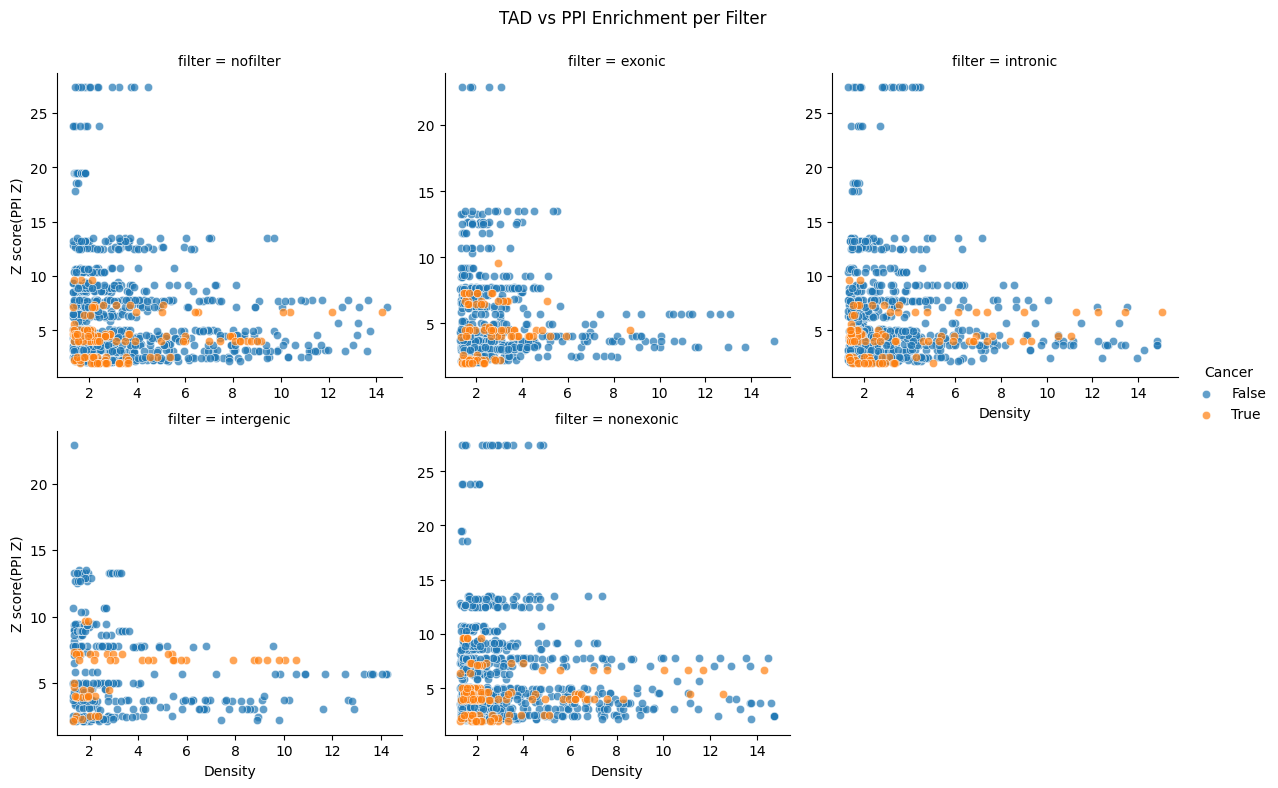

In [234]:
mask = (combined_df['pval_border'] < 0.05) & (combined_df['z_score'] > 2)
sign_df = combined_df.loc[mask]
g = sns.FacetGrid(sign_df, col="filter", hue="is_cancer", height=4, col_wrap=3, sharex=False, sharey=False)
#sns.kdeplot(data=sign_df, x='z_score', hue='is_cancer', fill=True, common_norm=False)
#plt.axvline(x=2, color='red', linestyle='--', label='z = 2.0')
#plt.xlim(right=35)
#plt.xlabel('Z score(PPI enrichment)')


g.map(sns.scatterplot, 'log10_pval_border', "z_score", alpha=0.7)
g.add_legend(title='Cancer')
g.set_axis_labels("Density", "Z score(PPI Z)")
#g.set_axvline(x=2, color='red', linestyle='--', label='z = 2.0')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('TAD vs PPI Enrichment per Filter')
plt.show()


In [186]:
print(combined_df.groupby('is_cancer')['pval_border'].describe())
print(combined_df.groupby('is_cancer')['z_score'].describe())


             count     mean       std           min       25%       50%  \
is_cancer                                                                 
False      11559.0  0.26144  0.264502  9.645618e-16  0.033143  0.172155   
True        1898.0  0.24727  0.272550  9.005142e-16  0.035682  0.134416   

                75%      max  
is_cancer                     
False      0.428021  1.00000  
True       0.385925  0.99962  
             count      mean       std       min       25%       50%  \
is_cancer                                                              
False      11559.0  5.835247  5.634391 -1.169455  2.452691  4.062531   
True        1898.0  4.753019  2.712529  1.734222  2.178448  4.372922   

                75%        max  
is_cancer                       
False      7.685850  43.339920  
True       6.718986  10.875403  


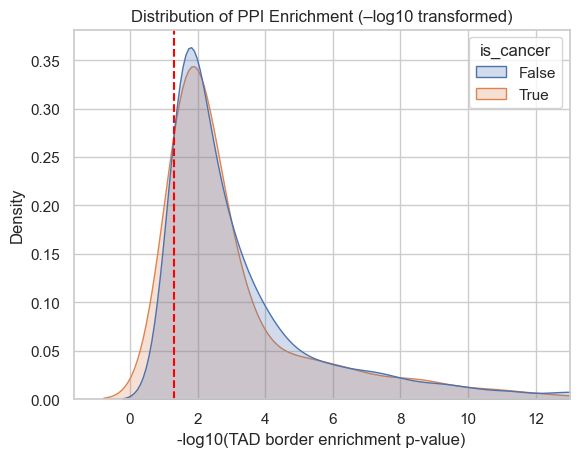

In [268]:
import numpy as np

mask = combined_df['pval_border'] < 0.05
sign_df = combined_df.loc[mask]
sns.kdeplot(data=sign_df, x='log10_pval_border', hue='is_cancer', fill=True, common_norm=False)
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
plt.xlim(right=13)
plt.xlabel('-log10(TAD border enrichment p-value)')
plt.title('Distribution of PPI Enrichment (–log10 transformed)')
plt.show()


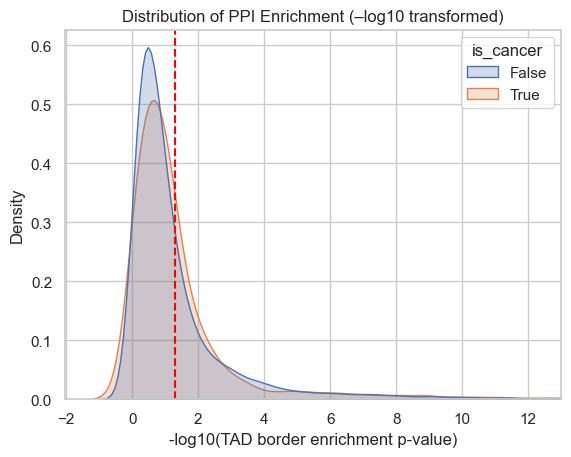

In [269]:
import numpy as np


sns.kdeplot(data=combined_df, x='log10_pval_border', hue='is_cancer', fill=True, common_norm=False)
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
plt.xlim(right=13)
plt.xlabel('-log10(TAD border enrichment p-value)')
plt.title('Distribution of PPI Enrichment (–log10 transformed)')
plt.show()



/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_49830/559435221.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  g.fig.show()


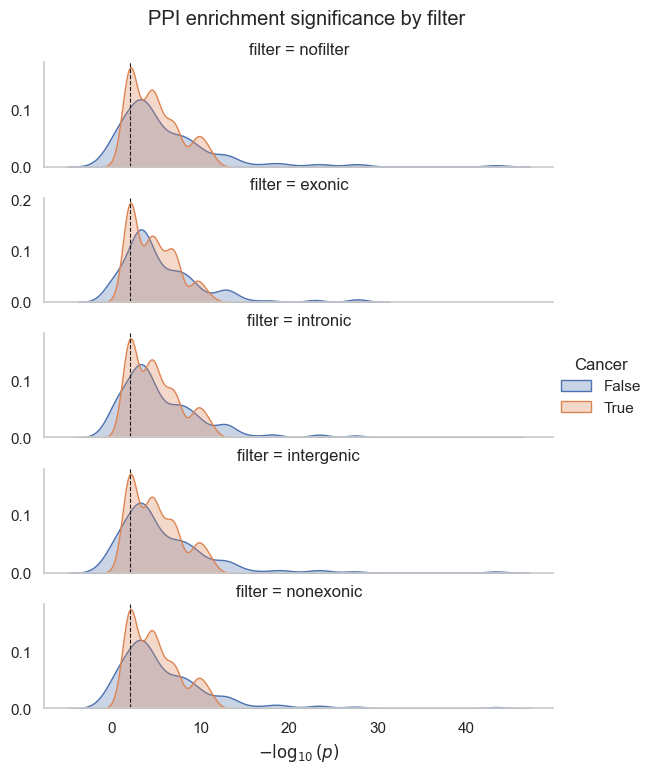

In [60]:
g = sns.FacetGrid(combined_df, row='filter', hue='is_cancer', height=1.5,
                  aspect=4, sharex=True, sharey=False)
g.map_dataframe(sns.kdeplot, x='z_score', fill=True, alpha=.3)
g.add_legend(title="Cancer")
for ax in g.axes.flat:
    ax.axvline(2, color='k', ls='--', lw=.8)
    ax.set_ylabel('')
g.set_axis_labels(r"$-\log_{10}(p)$", "")
g.fig.subplots_adjust(hspace=.3)
g.fig.suptitle("PPI enrichment significance by filter", y=1.02)
g.fig.show()
#g.savefig(f"{path}/ppi_enrich_kde_facets.pdf", bbox_inches='tight')


In [66]:
import seaborn as sns, matplotlib.pyplot as plt, pandas as pd, scipy.stats as st

def violin_pval(df, path=None):
    """
    df columns: ['filter','is_cancer', 'lpval'] where lpval = -log10(p)
    """
    sns.set_context("paper", font_scale=1.1)
    palette = {False: '#4878CF', True: '#D65F5F'}

    plt.figure(figsize=(6,4))
    ax = sns.violinplot(data=df, x='filter', y='log10_pval_ppi', hue='is_cancer',
                        split=True, inner=None, palette=palette, cut=0)
    sns.boxplot(data=df, x='filter', y='log10_pval_ppi', hue='is_cancer',
                showcaps=False, width=.15, palette=['white']*2,
                fliersize=0, dodge=True)

    # Annotate MW p‑values
    for i, f in enumerate(df['filter'].unique()):
        c  = df.query("filter == @f and is_cancer == True")['log10_pval_ppi']
        nc = df.query("filter == @f and is_cancer == False")['log10_pval_ppi']
        U, p = st.mannwhitneyu(c, nc, alternative='two-sided')
        ax.text(i, max(df['log10_pval_ppi'])*1.05, f"p={p:.2e}", ha='center', fontsize=8)

    ax.axhline(y=-np.log10(0.05), ls='--', lw=1, color='k',
               label=r'$p=0.05$ threshold')
    ax.set_xlabel("Genomic filter")
    ax.set_ylabel(r"$-\log_{10}(p_{\mathrm{enrichment}})$")
    #ax.legend_.remove()
    plt.tight_layout()
    #plt.savefig(f"{path}/ppi_enrich_violin.pdf")
    plt.show()
    plt.close()


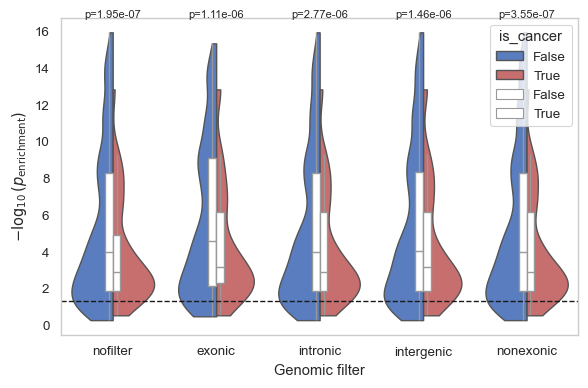

In [67]:
violin_pval(combined_df)

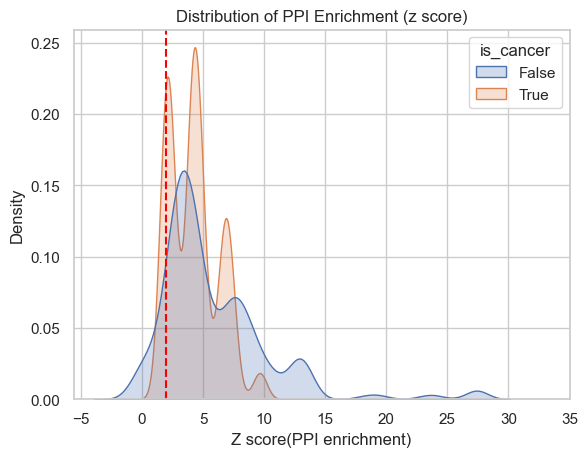

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=sign_df, x='z_score', hue='is_cancer', fill=True, common_norm=False)
plt.axvline(x=2, color='red', linestyle='--', label='z = 2.0')
plt.xlim(right=35)
plt.xlabel('Z score(PPI enrichment)')
plt.title('Distribution of PPI Enrichment (z score)')
plt.show()

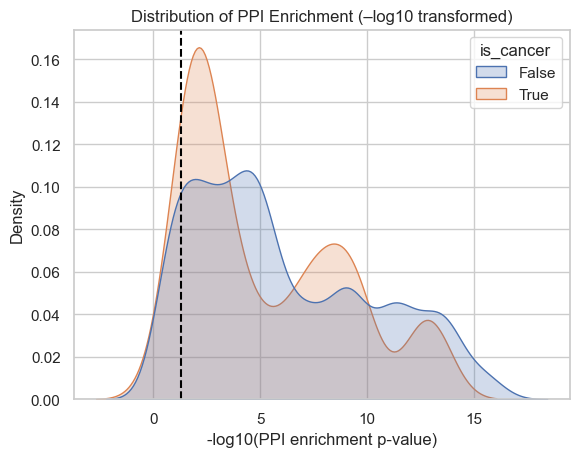

In [278]:
sns.kdeplot(data=sign_df, x='log10_pval_ppi', hue='is_cancer', fill=True, common_norm=False)
plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')

plt.xlabel('-log10(PPI enrichment p-value)')
plt.title('Distribution of PPI Enrichment (–log10 transformed)')
plt.show()

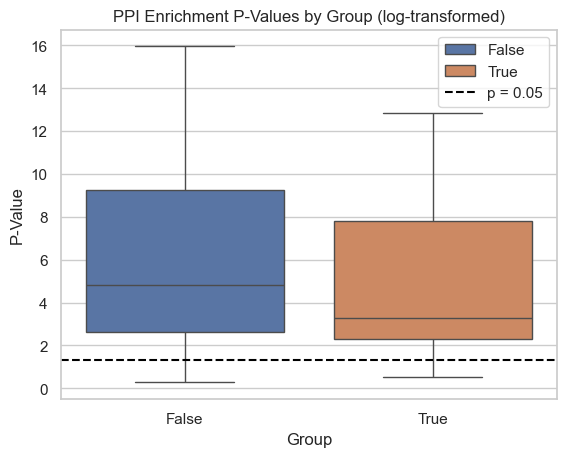

In [276]:
mask = combined_df['pval_border'] < 0.05
sign_df = combined_df.loc[mask]
sns.boxplot(x='is_cancer', y='log10_pval_ppi', hue="is_cancer", data=sign_df)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
plt.title('PPI Enrichment P-Values by Group (log-transformed)')
plt.ylabel('P-Value')
plt.xlabel('Group')
plt.legend()
plt.show()


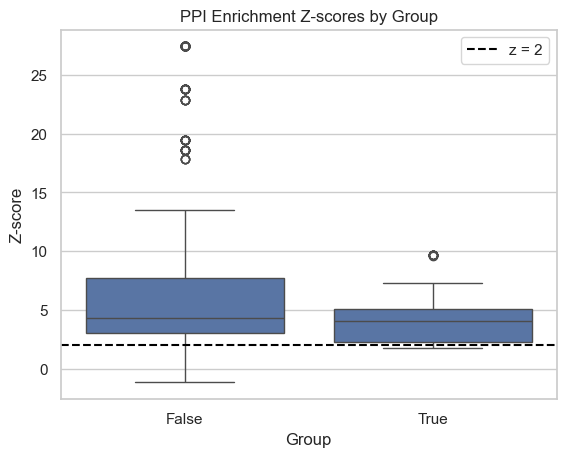

In [279]:
sns.boxplot(x='is_cancer', y='z_score', data=sign_df)
plt.axhline(y=2, color='black', linestyle='--', label='z = 2')
plt.legend()
plt.title('PPI Enrichment Z-scores by Group')
plt.ylabel('Z-score')
plt.xlabel('Group')
plt.show()


In [40]:
from scipy.stats import mannwhitneyu

filtered = combined_df[combined_df['filter'] == 'intergenic']
cancer_vals = filtered[filtered['is_cancer']]['pvalue']
noncancer_vals = filtered[~filtered['is_cancer']]['pvalue']

u, p = mannwhitneyu(cancer_vals, noncancer_vals, alternative='two-sided')
print(f"Mann-Whitney U test: U={u:.2f}, p-value={p:.3e}")


Mann-Whitney U test: U=531318.00, p-value=1.462e-06


In [46]:
cancer_vals.values, noncancer_vals.values

(array([1.560e-08, 6.550e-07, 2.906e-01, 1.300e-03, 1.660e-07, 6.700e-04,
        4.900e-03, 1.400e-02, 2.150e-02, 4.500e-10, 4.000e-03, 5.300e-04,
        3.120e-05, 4.600e-03, 4.170e-02, 2.800e-04, 1.430e-13, 3.270e-02,
        4.000e-03, 3.030e-02, 3.470e-05, 5.510e-09, 1.560e-08, 6.550e-07,
        2.906e-01, 1.300e-03, 1.660e-07, 6.700e-04, 4.900e-03, 1.400e-02,
        2.150e-02, 4.500e-10, 4.000e-03, 5.300e-04, 3.120e-05, 4.600e-03,
        4.170e-02, 2.800e-04, 1.430e-13, 3.270e-02, 4.000e-03, 3.030e-02,
        3.470e-05, 5.510e-09, 1.560e-08, 6.550e-07, 2.906e-01, 1.300e-03,
        1.660e-07, 6.700e-04, 4.900e-03, 1.400e-02, 2.150e-02, 4.500e-10,
        4.000e-03, 5.300e-04, 3.120e-05, 4.600e-03, 4.170e-02, 2.800e-04,
        1.430e-13, 3.270e-02, 4.000e-03, 3.030e-02, 3.470e-05, 5.510e-09,
        1.560e-08, 6.550e-07, 2.906e-01, 1.300e-03, 1.660e-07, 6.700e-04,
        4.900e-03, 1.400e-02, 2.150e-02, 4.500e-10, 4.000e-03, 5.300e-04,
        3.120e-05, 4.600e-03, 4.170e-0

/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_49830/3217432339.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_df, x='is_cancer', y='z_score', palette={'True':'#D65F5F', 'False':'#4878CF'}, inner='quart')


<Axes: xlabel='is_cancer', ylabel='z_score'>

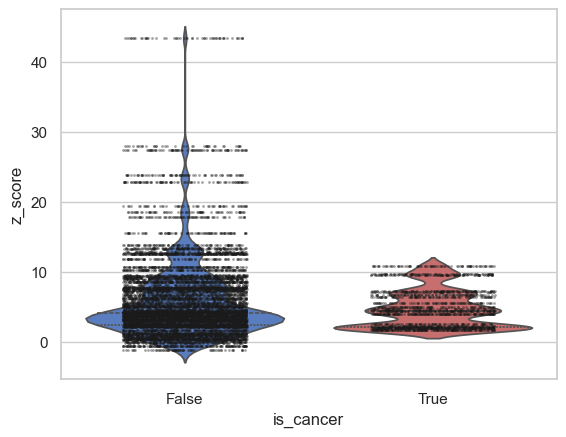

In [51]:
sns.violinplot(data=combined_df, x='is_cancer', y='z_score', palette={'True':'#D65F5F', 'False':'#4878CF'}, inner='quart')
sns.stripplot(data=combined_df, x='is_cancer', y='z_score',
              jitter=.25, size=2, color='k', alpha=.4, rasterized=True)


In [ ]:
sns.boxplot(data=[cancer_vals.values, noncancer_vals.values], width=.15, showcaps=False,
            boxprops={'facecolor':'none'}, whis=[0,100])
sns.swarmplot(data=[cancer_vals.values, noncancer_vals.values], color='k', alpha=.45, size=2)

U, p = mannwhitneyu(cancer_vals.values, noncancer_vals.values, alternative='two-sided')
plt.text(0.5, 1.05, f"Mann‑Whitney U = {U:.0f}, p = {p:.3g}",
         ha='center', transform=plt.gca().transAxes)

/Users/aliaarman/TADandPPI/.venv/lib/python3.13/site-packages/dabest/plot_tools.py:2537: UserWarning: 97.8% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


KeyboardInterrupt: 

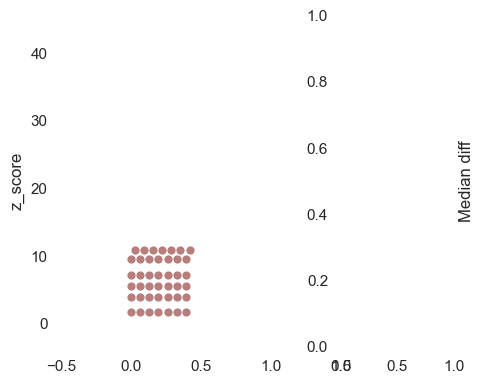

In [57]:
import dabest
d = dabest.load(combined_df, x='is_cancer', y='z_score', idx=(True, False))
fig = d.mean_diff.plot(custom_palette=['#D65F5F','#4878CF'],
                       float_contrast=True,
                       contrast_label='Median diff')


In [363]:
from scipy.stats import mannwhitneyu

filtered = combined_df[combined_df['filter'] == 'nofilter']
cancer_vals = combined_df[combined_df['is_cancer']]['z_score']
noncancer_vals = combined_df[~combined_df['is_cancer']]['z_score']

u, p = mannwhitneyu(cancer_vals, noncancer_vals, alternative='two-sided')
print(f"Mann-Whitney U test: U={u:.2f}, p-value={p:.3e}")


Mann-Whitney U test: U=10542363.00, p-value=6.468e-03


In [362]:
from scipy.stats import mannwhitneyu

cancer_vals = combined_df[combined_df['is_cancer']]['pval_border']
noncancer_vals = combined_df[~combined_df['is_cancer']]['pval_border']

#filtered = combined_df[combined_df['filter'] == 'nonexonic']
#cancer_vals = filtered[filtered['is_cancer']]['pval_border']
#noncancer_vals = filtered[~filtered['is_cancer']]['pval_border']

u, p = mannwhitneyu(cancer_vals, noncancer_vals, alternative='two-sided')
print(f"Mann-Whitney U test: U={u:.2f}, p-value={p:.3e}")

Mann-Whitney U test: U=10595482.00, p-value=1.711e-02


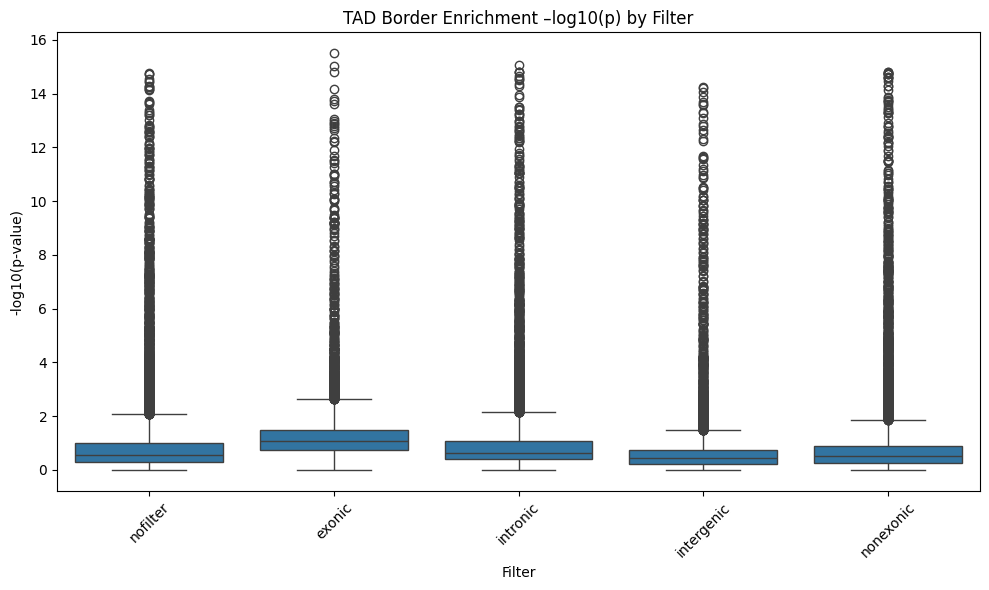

In [199]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='filter', y='log10_pval_border', data=df)
plt.title('TAD Border Enrichment –log10(p) by Filter')
plt.ylabel('-log10(p-value)')
plt.xlabel('Filter')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


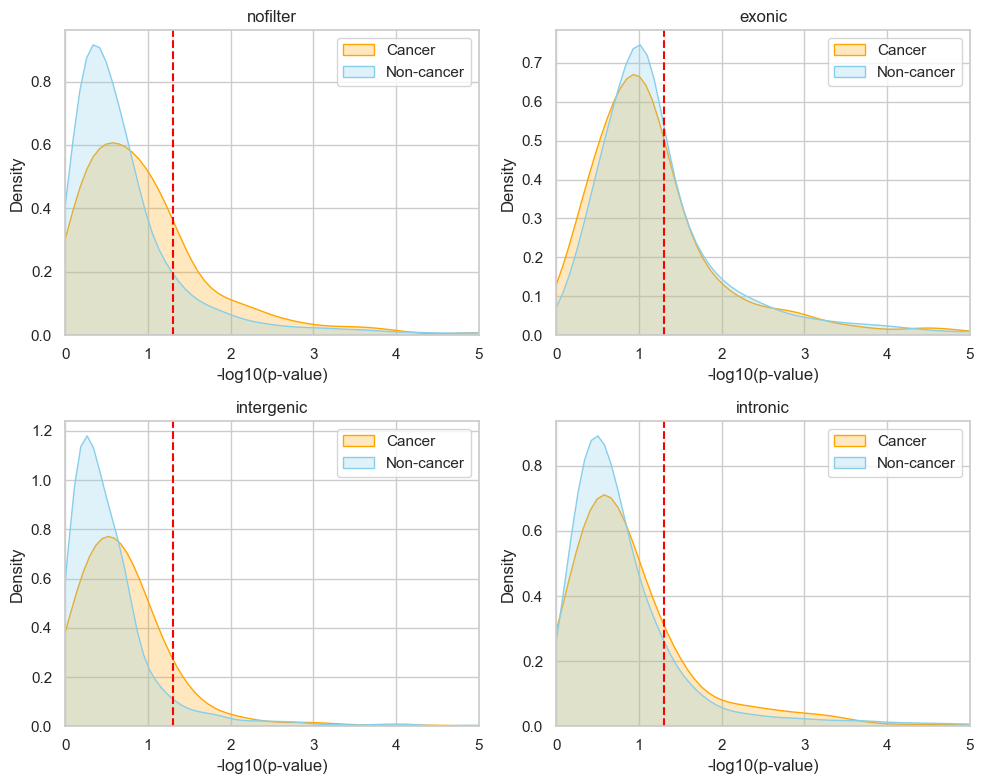

In [348]:
# Example: df contains columns ['log10_pval', 'disease_type']
# disease_type is 'cancer' or 'non-cancer'

# Kernel Density Estimation for both groups
filters = ['nofilter', 'exonic', 'intergenic', 'intronic']
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
#figure.suptitle(f"Histograms of Filters", fontsize=16)

        
axes = axes.flatten()

for i, filter in enumerate(filters):
    df_filtered = df[df['filter'] == filter]
    cancer = df_filtered[df_filtered['is_cancer'] == True]['log10_pval_border']
    non_cancer = df_filtered[df_filtered['is_cancer'] == False]['log10_pval_border']
    cancer = cancer[np.isfinite(cancer)]
    non_cancer = non_cancer[np.isfinite(non_cancer)]


    sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=-np.log10(0.05), color='red', linestyle='--')
    axes[i].set_xlabel('-log10(p-value)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'enrichment_analysis_string.png', dpi=300, bbox_inches='tight')
plt.show()


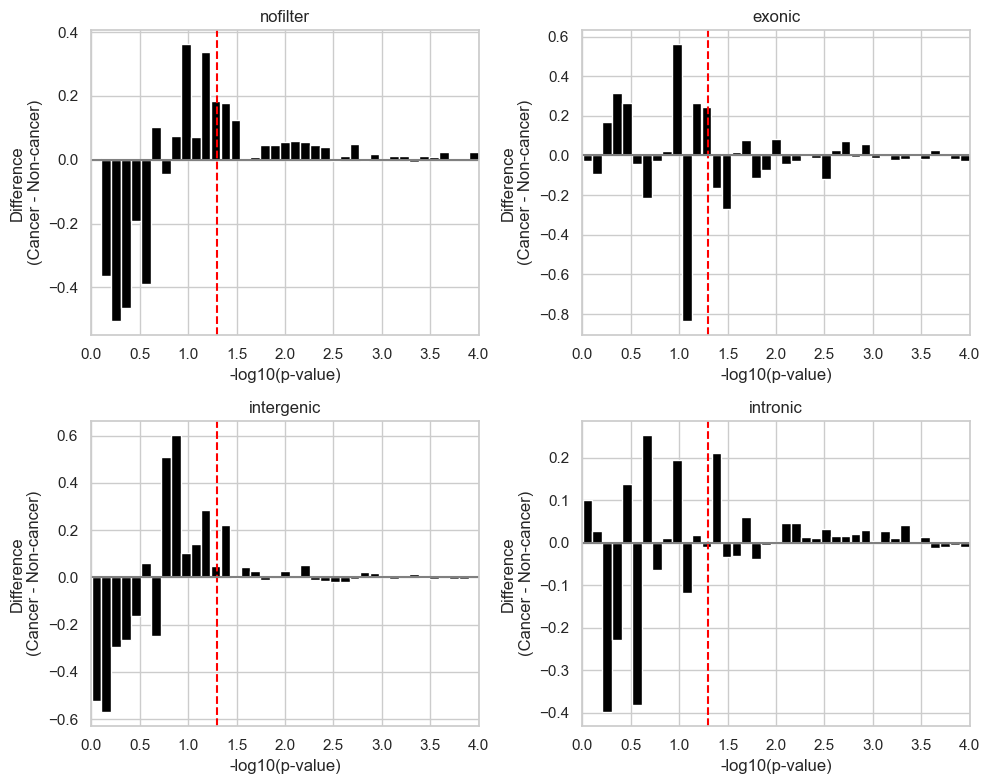

In [347]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

bins = np.linspace(0, 4, 40)

for i, filter in enumerate(filters):
    df_filtered = df[df['filter'] == filter]
    
    cancer = df_filtered[df_filtered['is_cancer'] == True]['log10_pval_border']
    non_cancer = df_filtered[df_filtered['is_cancer'] == False]['log10_pval_border']
    cancer = cancer[np.isfinite(cancer)]
    non_cancer = non_cancer[np.isfinite(non_cancer)]
    
    # compute histograms (no ax here)
    cancer_hist, _ = np.histogram(cancer, bins=bins, density=True)
    non_cancer_hist, _ = np.histogram(non_cancer, bins=bins, density=True)

    diff = cancer_hist - non_cancer_hist
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # plot bar chart on subplot
    axes[i].bar(bin_centers, diff, width=0.1, color='black')
    axes[i].axvline(x=-np.log10(0.05), color='red', linestyle='--', label="p = 0.05")
    axes[i].axhline(y=0, color='gray')
    axes[i].set_xlim(0, 4)
    axes[i].set_xlabel('-log10(p-value)')
    axes[i].set_ylabel('Difference\n(Cancer - Non-cancer)')
    axes[i].set_title(f"{filter}")

plt.tight_layout()
#plt.savefig('cancer_non_difference_plot_sign_string.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
combined = pd.concat([df_cancers, df_noncancers])

In [ ]:
combined_df = pd.merge(df, combined, on='diseaseId', how='inner', indicator=True)

In [283]:
combined_df['region'] = np.nan

mask_10 = (combined_df['pval_border'] > 0.05) & (combined_df['z_score'] > 2.0)
mask_11 = (combined_df['pval_border'] <= 0.05) & (combined_df['z_score'] > 2.0)
mask_00 = (combined_df['pval_border'] > 0.05) & (combined_df['z_score'] <= 2.0)
mask_01 = (combined_df['pval_border'] <= 0.05) & (combined_df['z_score'] <= 2.0)

combined_df.loc[mask_10, 'region'] = '10'
combined_df.loc[mask_11, 'region'] = '11'
combined_df.loc[mask_00, 'region'] = '00'
combined_df.loc[mask_01, 'region'] = '01'


/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_74020/1145037139.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_df.loc[mask_10, 'region'] = '10'


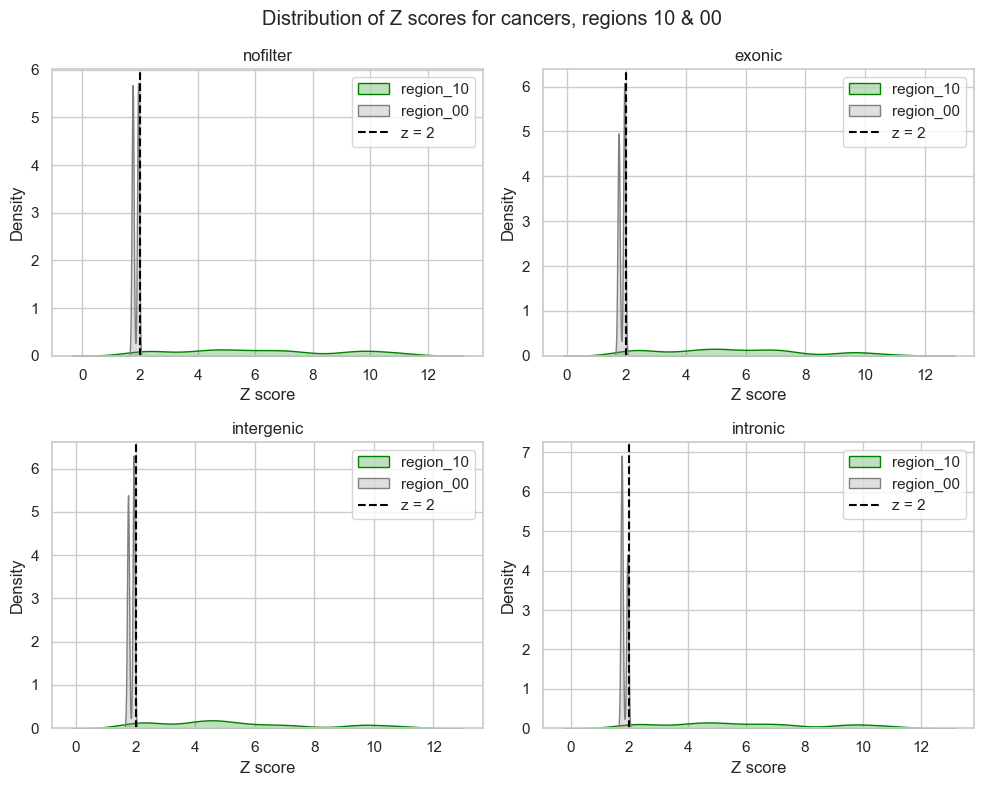

In [301]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of Z scores for cancers, regions 10 & 00')
        
axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == True]
    region_10 = combined_filtered[combined_filtered['region'].isin(['10'])]['z_score']
    region_00 = combined_filtered[combined_filtered['region'].isin(['00'])]['z_score']
    
    region_10 = region_10[np.isfinite(region_10)]
    region_00 = region_00[np.isfinite(region_00)]


    sns.kdeplot(region_10, label='region_10', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_00, label='region_00', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #sns.kdeplot(region_11, label='region_10', color='green', fill=True, common_norm=False, ax=axes[i])
    #sns.kdeplot(region_10, label='region_00', color='gray', fill=True, common_norm=False, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=2, color='black', linestyle='--', label="z = 2")
    axes[i].set_xlabel('Z score')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'cancer_non_z _score_10&00_nonsign_string.png', dpi=300, bbox_inches='tight')
plt.show()


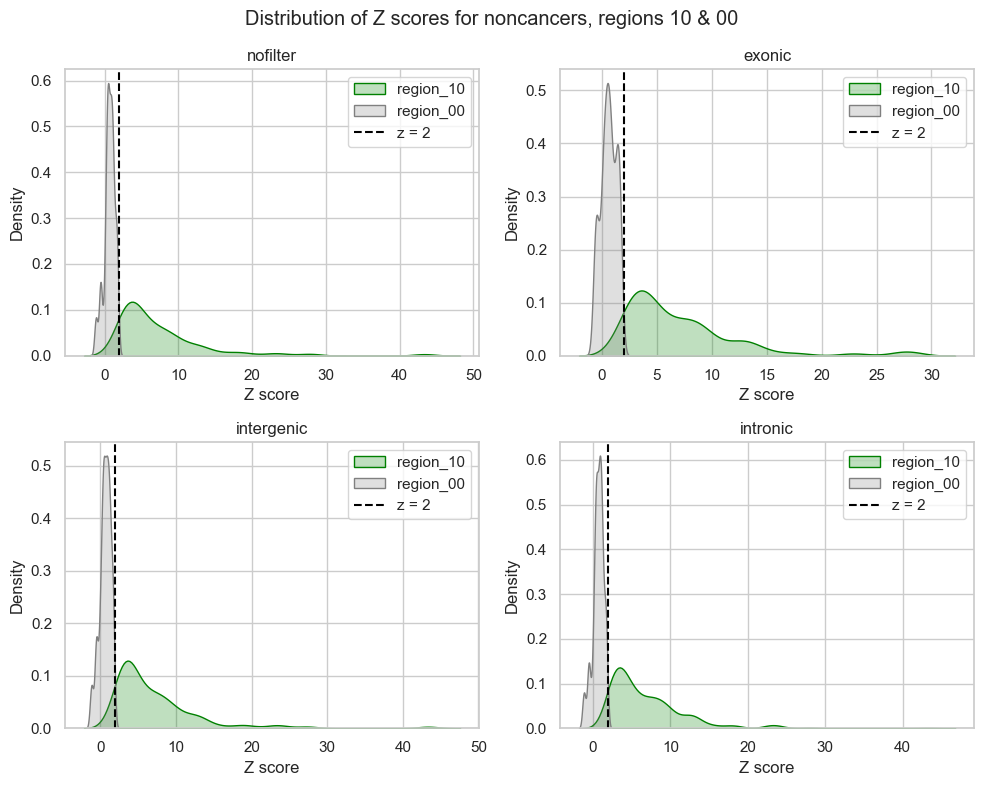

In [302]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of Z scores for noncancers, regions 10 & 00')
        
axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == False]
    region_11 = combined_filtered[combined_filtered['region'].isin(['10'])]['z_score']
    region_10 = combined_filtered[combined_filtered['region'].isin(['00'])]['z_score']
    
    region_11 = region_11[np.isfinite(region_11)]
    region_10 = region_10[np.isfinite(region_10)]


    #sns.kdeplot(region_11, label='region_10', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #sns.kdeplot(region_10, label='region_00', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_11, label='region_10', color='green', fill=True, common_norm=False, ax=axes[i])
    sns.kdeplot(region_10, label='region_00', color='gray', fill=True, common_norm=False, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=2, color='black', linestyle='--', label="z = 2")
    axes[i].set_xlabel('Z score')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'noncancer_non_z _score_10&00_nonsign_string.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_74020/3334321685.py:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(region_01, label='region_01', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])


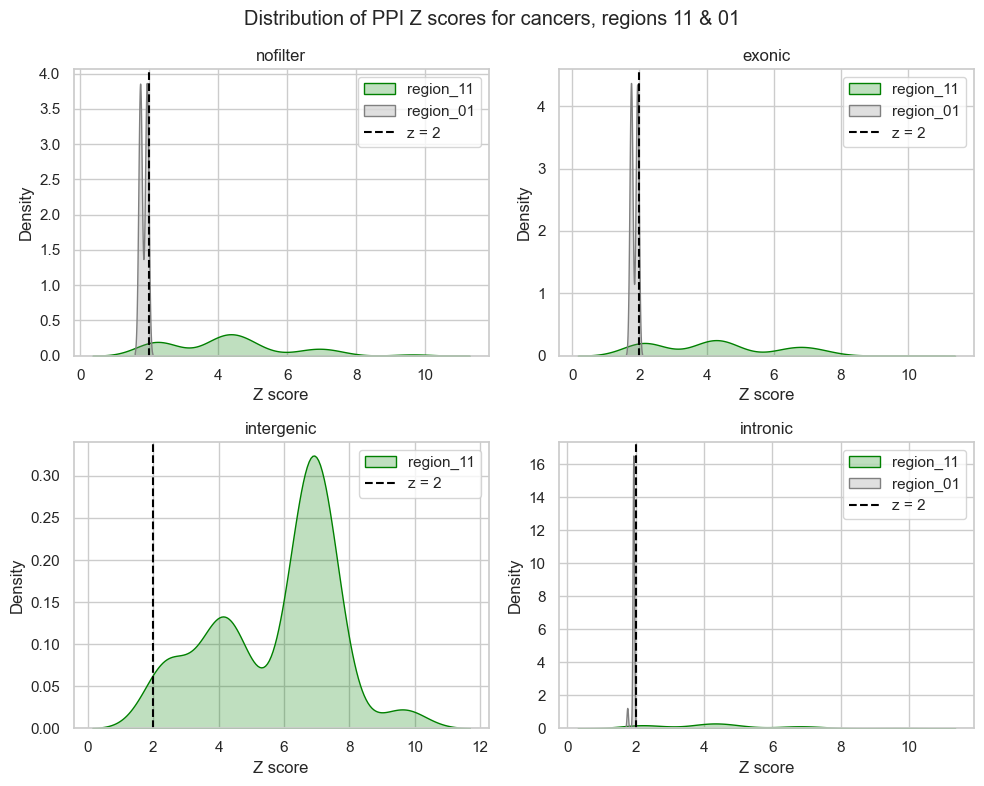

In [303]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of PPI Z scores for cancers, regions 11 & 01')

axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == True]
    region_11 = combined_filtered[combined_filtered['region'].isin(['11'])]['z_score']
    region_01 = combined_filtered[combined_filtered['region'].isin(['01'])]['z_score']
    
    region_11 = region_11[np.isfinite(region_11)]
    region_01 = region_01[np.isfinite(region_01)]


    sns.kdeplot(region_11, label='region_11', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_01, label='region_01', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=2, color='black', linestyle='--', label="z = 2")
    axes[i].set_xlabel('Z score')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'cancer_z_score_kde_11&01_sign_string.png', dpi=300, bbox_inches='tight')
plt.show()


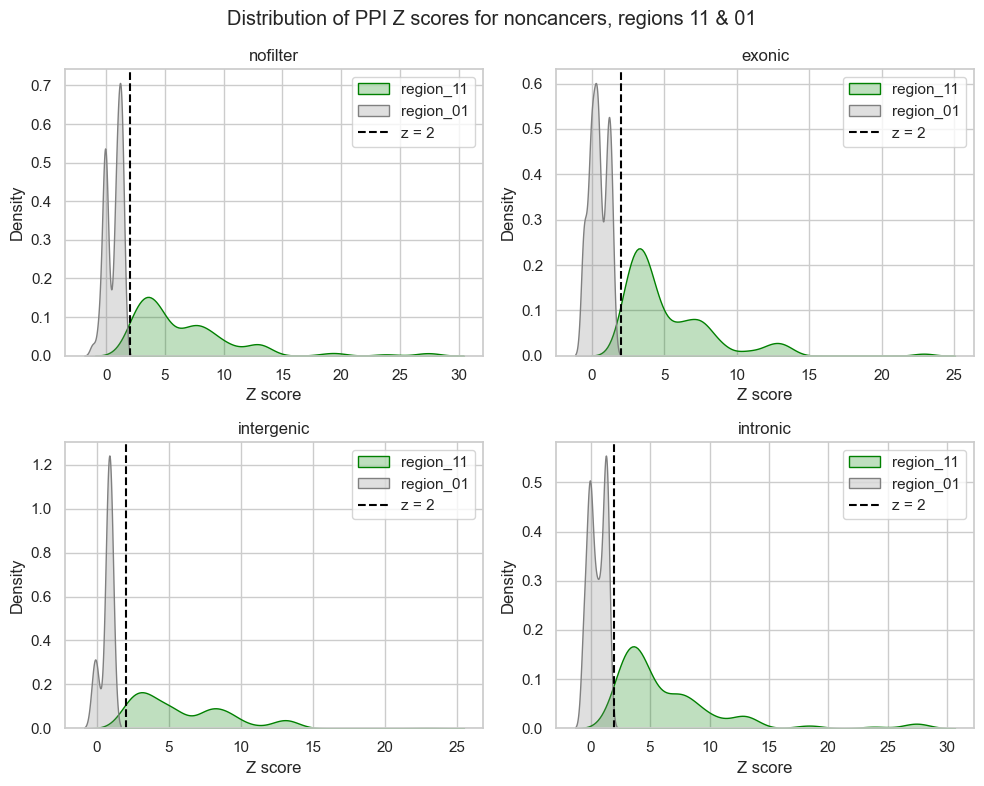

In [304]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of PPI Z scores for noncancers, regions 11 & 01')

axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == False]
    region_11 = combined_filtered[combined_filtered['region'].isin(['11'])]['z_score']
    region_01 = combined_filtered[combined_filtered['region'].isin(['01'])]['z_score']
    
    region_11 = region_11[np.isfinite(region_11)]
    region_01 = region_01[np.isfinite(region_01)]


    sns.kdeplot(region_11, label='region_11', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_01, label='region_01', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=2, color='black', linestyle='--', label="z = 2")
    axes[i].set_xlabel('Z score')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'noncancer_z_score_kde_11&01_sign_string.png', dpi=300, bbox_inches='tight')
plt.show()


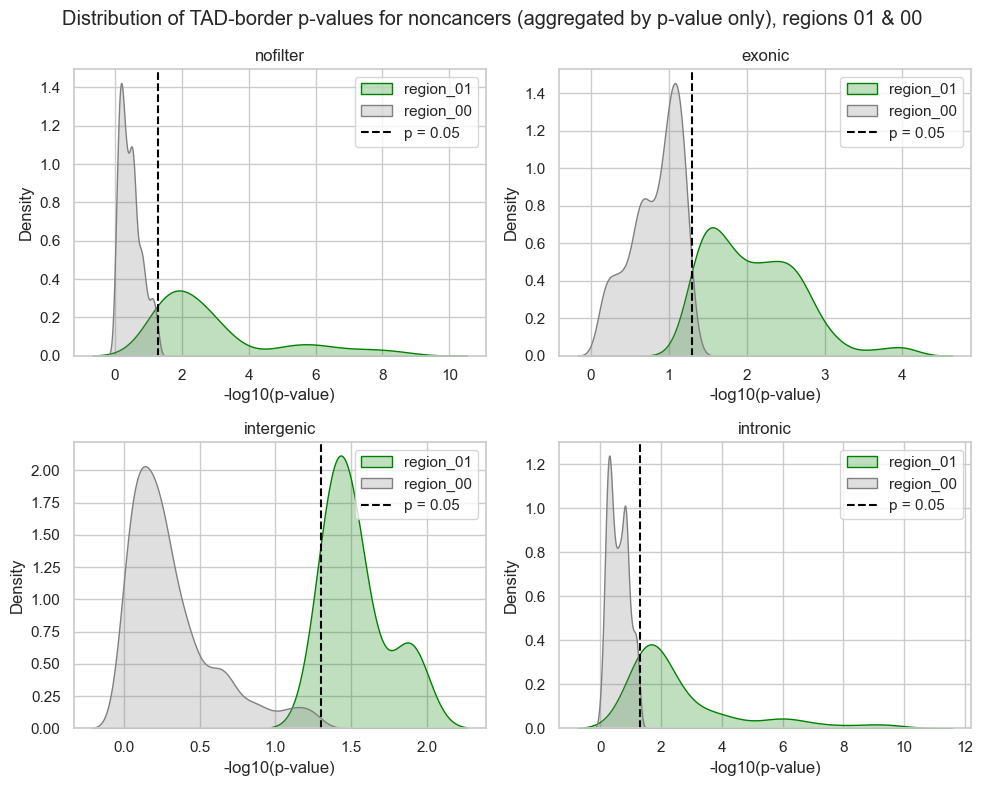

In [305]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of TAD-border p-values for noncancers (aggregated by p-value only), regions 01 & 00')

axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == False]
    region_00 = combined_filtered[combined_filtered['region'].isin(['00'])]['log10_pval_border']
    region_01 = combined_filtered[combined_filtered['region'].isin(['01'])]['log10_pval_border']
    
    region_00 = region_00[np.isfinite(region_00)]
    region_01 = region_01[np.isfinite(region_01)]


    sns.kdeplot(region_01, label='region_01', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_00, label='region_00', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
    axes[i].set_xlabel('-log10(p-value)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'noncancer_tad_pval_nonsign_kde_00&01_string.png', dpi=300, bbox_inches='tight')
plt.show()


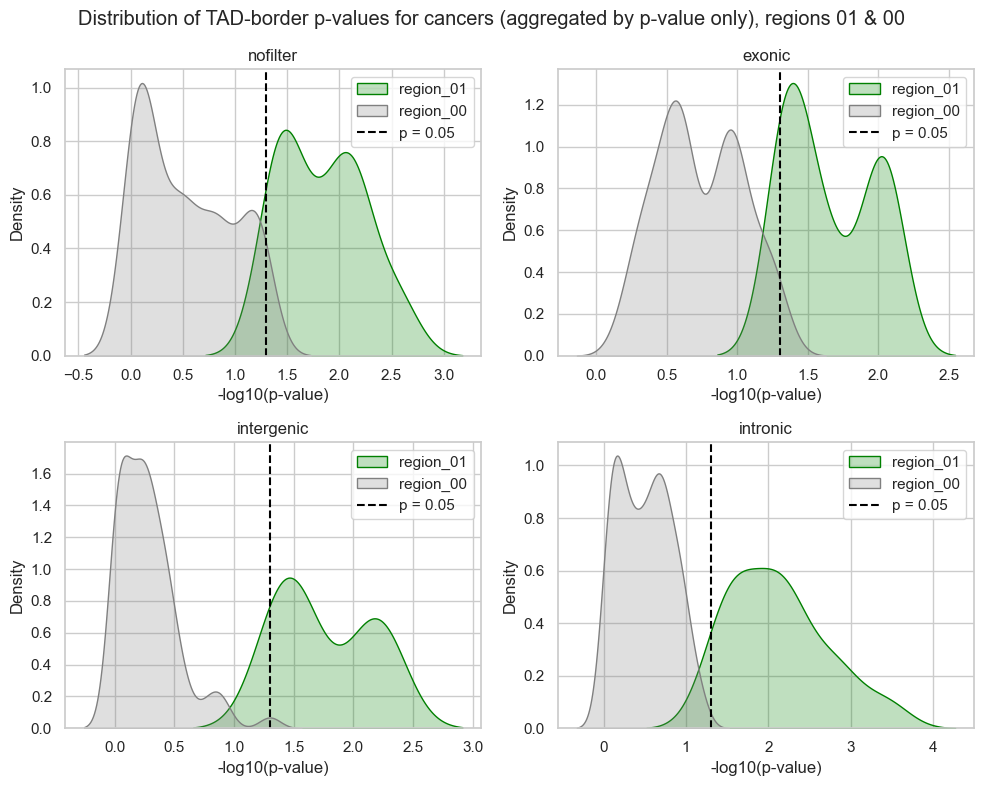

In [306]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of TAD-border p-values for cancers (aggregated by p-value only), regions 01 & 00')

axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == True]
    region_00 = combined_filtered[combined_filtered['region'].isin(['00'])]['log10_pval_border']
    region_01 = combined_filtered[combined_filtered['region'].isin(['01'])]['log10_pval_border']
    
    region_00 = region_00[np.isfinite(region_00)]
    region_01 = region_01[np.isfinite(region_01)]


    sns.kdeplot(region_01, label='region_01', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_00, label='region_00', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
    axes[i].set_xlabel('-log10(p-value)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'cancer_tad_pval_nonsign_kde_00&01_string.png', dpi=300, bbox_inches='tight')
plt.show()

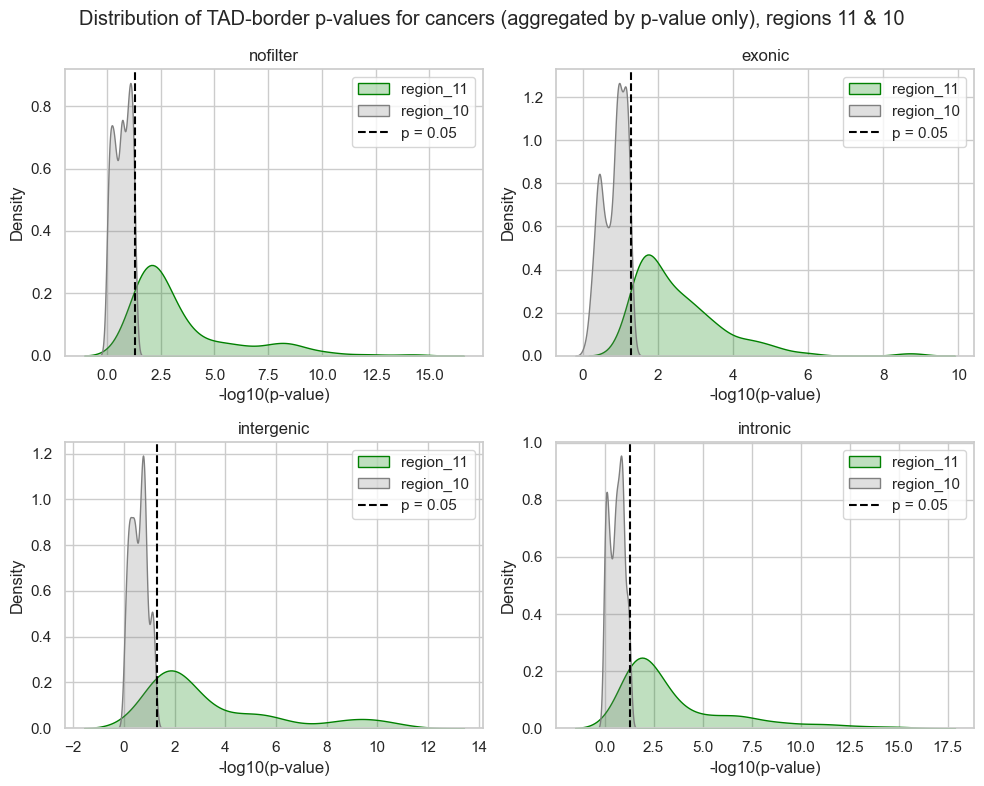

In [307]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of TAD-border p-values for cancers (aggregated by p-value only), regions 11 & 10')

axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == True]
    region_00 = combined_filtered[combined_filtered['region'].isin(['10'])]['log10_pval_border']
    region_01 = combined_filtered[combined_filtered['region'].isin(['11'])]['log10_pval_border']
    
    region_00 = region_00[np.isfinite(region_00)]
    region_01 = region_01[np.isfinite(region_01)]


    sns.kdeplot(region_01, label='region_11', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_00, label='region_10', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
    axes[i].set_xlabel('-log10(p-value)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'cancer_tad_pval_sign_kde_11&10_string.png', dpi=300, bbox_inches='tight')
plt.show()

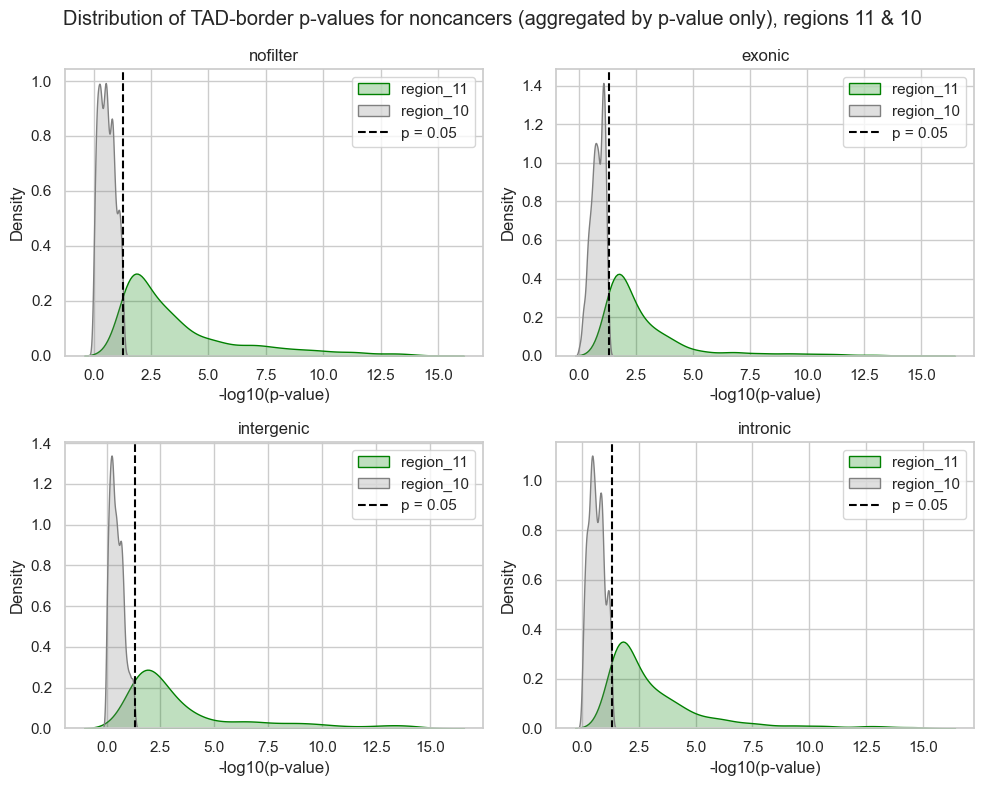

In [308]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
figure.suptitle('Distribution of TAD-border p-values for noncancers (aggregated by p-value only), regions 11 & 10')

axes = axes.flatten()

for i, filter in enumerate(filters):
    combined_filtered = combined_df[combined_df['filter'] == filter]
    combined_filtered =  combined_filtered[combined_filtered['is_cancer'] == False]
    region_00 = combined_filtered[combined_filtered['region'].isin(['10'])]['log10_pval_border']
    region_01 = combined_filtered[combined_filtered['region'].isin(['11'])]['log10_pval_border']
    
    region_00 = region_00[np.isfinite(region_00)]
    region_01 = region_01[np.isfinite(region_01)]


    sns.kdeplot(region_01, label='region_11', color='green', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    sns.kdeplot(region_00, label='region_10', color='gray', fill=True, common_norm=False, bw_adjust=0.8, ax=axes[i])
    #axes[i].set_xlim(0, 5)
    axes[i].set_title(f"{filter}")
    axes[i].axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p = 0.05')
    axes[i].set_xlabel('-log10(p-value)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    
    #plt.figure(figsize=(6,4))
    #plt.xlim(0, 4)
    #sns.kdeplot(cancer, label='Cancer', color='orange', fill=True, common_norm=False, bw_adjust=0.8)
    #sns.kdeplot(non_cancer, label='Non-cancer', color='skyblue', fill=True, common_norm=False, bw_adjust=0.8)



plt.tight_layout()
plt.savefig(f'noncancer_tad_pval_sign_kde_11&10_string.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#mask = (combined_df['pval_border'] == 0.0) | (combined_df['pval_border'].isna())
#combined_df.loc[mask, 'pval_border'] = combined_df.loc[mask, 'p_empirical']


In [16]:
filtered_df = combined_df[(combined_df['z_score'].notna()) & (combined_df['z_score'] != 0.0)]

sig_thresh = 2
filtered_df['ppi_is_significant'] = filtered_df['z_score'] >= sig_thresh


disease_fraction_df = filtered_df.groupby(['is_cancer', 'filter'])['ppi_is_significant'].mean().reset_index()
disease_fraction_df.rename(columns={'ppi_is_significant': 'ppi_disease_fraction'}, inplace=True)

In [18]:
filtered_df = combined_df[(combined_df['pval_border'].notna()) & (combined_df['pval_border'] != 0.0)]

sig_thresh = 0.05
filtered_df['is_significant'] = filtered_df['pval_border'] <= sig_thresh


disease_fraction_df = filtered_df.groupby(['is_cancer', 'filter'])['is_significant'].mean().reset_index()
disease_fraction_df.rename(columns={'is_significant': 'disease_fraction'}, inplace=True)

In [19]:
disease_fraction_df

,is_cancer,filter,disease_fraction
0,False,exonic,0.402501
1,False,intergenic,0.127768
2,False,intronic,0.316803
3,False,nofilter,0.330151
4,False,nonexonic,0.298239
5,True,exonic,0.300578
6,True,intergenic,0.147583
7,True,intronic,0.305913
8,True,nofilter,0.341146
9,True,nonexonic,0.339378


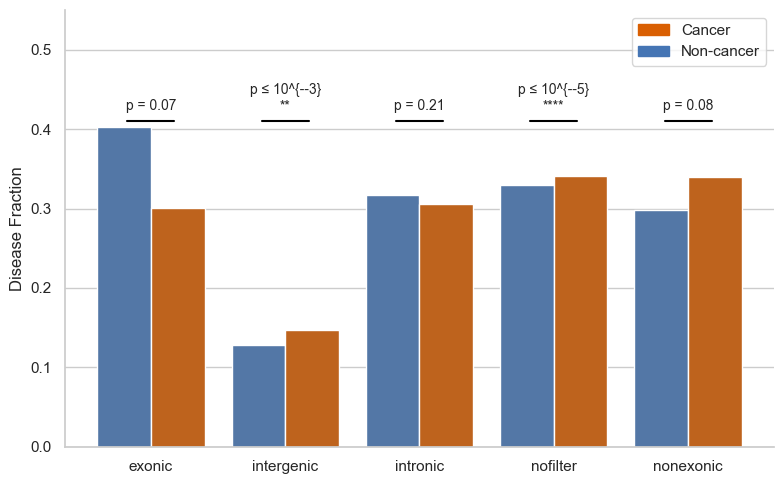

In [22]:
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.patches as mpatches
# Plot
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

# Grouped barplot
ax = sns.barplot(data=disease_fraction_df, x='filter', y='disease_fraction', hue='is_cancer', palette=['#4575b4', '#d95f02'])

# Annotate p-values
unique_filters = filtered_df['filter'].unique()
bar_width = 0.35
y_offset = 0.1

for i, filt in enumerate(unique_filters):
    sub_df = filtered_df[filtered_df['filter'] == filt]
    p_vals = sub_df['pval_border'].values
    
    cancer = sub_df[sub_df['is_cancer'] == True]['pval_border'].dropna()
    non_cancer = sub_df[sub_df['is_cancer'] == False]['pval_border'].dropna()

    # Skip if either group has fewer than 2 valid values
    if len(cancer) < 2 or len(non_cancer) < 2:
        continue

    # Welch's t-test (does not assume equal variances)
    stat, p = mannwhitneyu(cancer, non_cancer)

    # Format p-value and significance stars
    stars = '****' if p <= 1e-4 else '' if p > 0.05 else '**'
    text = f'p = {p:.2f}' if p >= 0.05 else f'p ≤ 10^{{-{int(np.floor(np.log10(p)))}}}'

    # Annotate above bars
    max_y = disease_fraction_df[disease_fraction_df['filter'] == filt]['disease_fraction'].max()
    x1, x2 = i - bar_width / 2, i + bar_width / 2
    y, h = max_y + y_offset, 0.01

    ax.plot([x1, x2], [0.41, 0.41], color='black')
    ax.text(i, 0.42, text + ('\n' + stars if stars else ''), ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 0.55)

# Labels
ax.set_ylabel('Disease Fraction')
ax.set_xlabel('')

cancer_patch = mpatches.Patch(color='#d95f02', label='Cancer')
noncancer_patch = mpatches.Patch(color='#4575b4', label='Non-cancer')
plt.legend(handles=[cancer_patch, noncancer_patch])
#plt.legend(title='', loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('sign_disease_pval_border_comparison.png')
plt.show()

